# Quadcopter hovering: feedback, system type, and steady-state error

This code implements the code for Lecture 7b of the Systems course (5EBS00). In this lecture, we consider a vertival quadcopter hovering scenario, define a controller, and validate the (analytically derived) system type through simulation.

## Input-output ODE

The ODE for the quadcopter hovering scenario is

$$m\ddot y(t)+c\dot y(t)=T(t)-mg+w(t).$$

where $y(t)$ is the altitude, $T(t)$ the upward thrust, and $w(t)$ an upward vertical wind force. At nominal hover and zero disturbance, $T_{\mathrm{hover}}=mg$. Thus, we simplify the ODE and define the control input as the thrust deviation

$$u(t)=T(t)-mg,$$

thereby removing the constant gravity term. This yields the input-output ODE

$${m\ddot y(t)+c\dot y(t)=u(t)+w(t)}.$$

For the specified coefficients, $T_{\mathrm{hover}}=0.5\cdot10=5$ N.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 4.8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "lines.linewidth": 2.2,
})

# Specified physical coefficients and controller gains
m = 0.5       # kg
c = 1.0       # N s/m
g = 10.0      # m/s^2

# Controller gains
kp = 1.0
kd = 0.2

T_hover = m * g
char_pol = np.array([m, c + kd, kp])
poles = np.roots(char_pol)

print(f"Hover thrust: {T_hover:.3f} N")
print(f"Closed-loop characteristic polynomial: {m:g} s^2 + {c+kd:g} s + {kp:g}")
print("Closed-loop poles:", np.array2string(poles, precision=6))

Hover thrust: 5.000 N
Closed-loop characteristic polynomial: 0.5 s^2 + 1.2 s + 1
Closed-loop poles: [-1.2+0.748331j -1.2-0.748331j]


In [19]:
# T_r maps the reference to altitude (Y_r = T_r R, with w=0).
# T_w maps the wind force to altitude (Y_w = T_w W, with r=0).
# Because the model is linear, the total altitude is y = y_r + y_w.
T_r = signal.TransferFunction([kd, kp], char_pol)
T_w = signal.TransferFunction([1.0], char_pol)

# The response function compute the response of a system to a given input u(t) over time t, assuming zero initial conditions.
def response(system, t, u):
    # Continuous-time response with zero initial conditions.
    tout, y, _ = signal.lsim(system, U=np.asarray(u), T=np.asarray(t))
    return tout, y

print("Reference-to-output T_r numerator/denominator:", T_r.num, T_r.den)
print("Disturbance-to-output T_w numerator/denominator:", T_w.num, T_w.den)

Reference-to-output T_r numerator/denominator: [0.4 2. ] [1.  2.4 2. ]
Disturbance-to-output T_w numerator/denominator: [2.] [1.  2.4 2. ]


## Reference tracking

We first analyze the tracking error to three different references, with zero disturbance, so $w=0$: constant, ramp, and parobala:

$$r_{\mathrm{constant}}=5,\qquad r_{\mathrm{ramp}}=t,\qquad r_{\mathrm{parabola}}=\tfrac12t^2,$$

These three reference signals correspond precisely to the three system types.

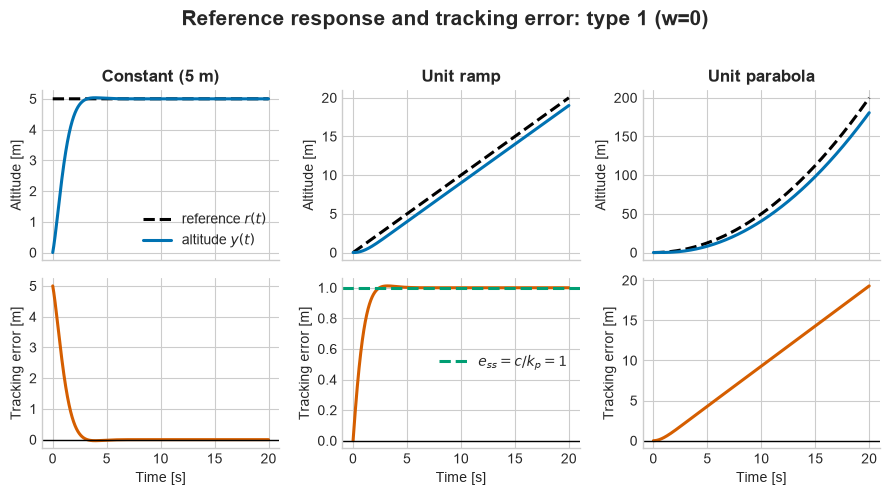

In [20]:
t = np.linspace(0.0, 20.0, 4001)
reference_tests = {
    "Constant (5 m)": 5.0 * np.ones_like(t),
    "Unit ramp": t,
    "Unit parabola": 0.5 * t**2,
}

fig, axes = plt.subplots(2, 3, figsize=(9, 5), sharex="col")
for column, (name, r) in enumerate(reference_tests.items()):
    # Enumerate over the three scenarios

    # Compute the response and error
    _, y = response(T_r, t, r)
    e = r - y

    altitude_ax = axes[0, column]
    error_ax = axes[1, column]

    # Plot altitude
    altitude_ax.plot(t, r, "--", color="black", label="reference $r(t)$")
    altitude_ax.plot(t, y, color="#0072B2", label="altitude $y(t)$")
    altitude_ax.set_title(name)
    altitude_ax.set_ylabel("Altitude [m]")
    if column == 0:
        altitude_ax.legend(loc="best")

    # Plot tracking error
    error_ax.plot(t, e, color="#D55E00")
    error_ax.axhline(0.0, color="black", linewidth=1)
    if name == "Unit ramp":
        error_ax.axhline(c / kp, linestyle="--", color="#009E73", label=r"$e_{ss}=c/k_p=1$")
        error_ax.legend(loc="best")
    error_ax.set_xlabel("Time [s]")
    error_ax.set_ylabel("Tracking error [m]")

fig.suptitle("Reference response and tracking error: type 1 (w=0)", fontsize=15, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

The derivative gain $k_d$ affects the transient response and pole locations, but it does not change the low-frequency type. As expected, the steady-state gain under the unit ramp only depends on $c$ and $k_p$.

## Disturbance rejection

Similarly, we now test three different disturbance signals, under the constant altitude signal $r(t)=5$:

$$w_{\mathrm{constant}}=1,\qquad w_{\mathrm{ramp}}=t,\qquad w_{\mathrm{parabola}}=\tfrac12t^2.$$

Again, these three disturbance signals correspond precisely to the three system types. As expected, as the system has type 0, even under a constant disturbance signal, there is a steady-state error.

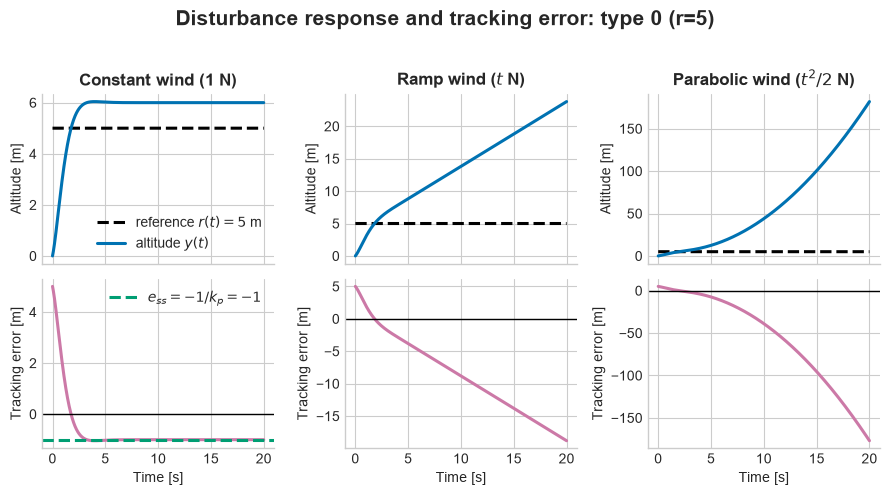

In [21]:
disturbance_tests = {
    "Constant wind (1 N)": np.ones_like(t),
    "Ramp wind ($t$ N)": t,
    "Parabolic wind ($t^2/2$ N)": 0.5 * t**2,
}

r_disturbance = 5.0 * np.ones_like(t)
_, y_reference_only = response(T_r, t, r_disturbance)

fig, axes = plt.subplots(2, 3, figsize=(9, 5), sharex="col")
for column, (name, w) in enumerate(disturbance_tests.items()):
    # Enumerate over the three scenarios
    
    # Compute the response and error
    _, y_from_w = response(T_w, t, w)
    y = y_reference_only + y_from_w
    e = r_disturbance - y

    altitude_ax = axes[0, column]
    error_ax = axes[1, column]

    # Plot altitude
    altitude_ax.plot(t, r_disturbance, "--", color="black", label="reference $r(t)=5$ m")
    altitude_ax.plot(t, y, color="#0072B2", label="altitude $y(t)$")
    altitude_ax.set_title(name)
    altitude_ax.set_ylabel("Altitude [m]")
    if column == 0:
        altitude_ax.legend(loc="best")

    # Plot tracking error
    error_ax.plot(t, e, color="#CC79A7")
    error_ax.axhline(0.0, color="black", linewidth=1)
    if name == "Constant wind (1 N)":
        error_ax.axhline(-1.0 / kp, linestyle="--", color="#009E73", label=r"$e_{ss}=-1/k_p=-1$")
        error_ax.legend(loc="best")
    error_ax.set_xlabel("Time [s]")
    error_ax.set_ylabel("Tracking error [m]")

fig.suptitle("Disturbance response and tracking error: type 0 (r=5)", fontsize=15, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Homework exercise (optional)

The current PD controller is unable to achieve a zero steady-state disturbance rejection. However, adding integral control into the controller (so making it a PID controller) can solve this. The transfer function for the PID controller is

$$D(s) = k_p + \frac{k_i}{s} + k_d s.$$

As a homework exercise, do the following:

1. Investigate how this PID controller changes the system type, compared to the lecture slides. Following slide 6, compute the system type for reference tracking and disturbance rejection for the PID controller.

2. Choose the integral gain $k_i = 0.2$ and update the notebook to incorporate the integral control. Hint, the important lines you need to change are the definitions of `char_pol`, `T_r`, and `T_w`.

3. Generate the plots as also presented in the notebook.

Send your solutions (the analytic type derivation, the notebook, and the plots) to thombadings@gmail.com in order for your answers to be graded.